# Car_Price_Prediction_Reference.ipynb

# 1. Project Introduction

### Objective
The primary objective of this project is to develop a robust, industry-level machine learning system to predict the selling price of used cars in the Indian automobile market. By leveraging historical data on various car attributes such as brand, mileage, fuel type, and engine capacity, we aim to provide accurate price estimations that can assist both buyers and sellers in making informed decisions.

### Key Goals:
- Build a comprehensive data processing pipeline.
- Compare multiple regression models to find the most accurate predictor.
- Export a production-ready model for deployment via Streamlit.
- Document every step for academic and professional reference.

# 2. Import Libraries

We will use standard data science libraries for data manipulation, visualization, and model development.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

try:
    from xgboost import XGBRegressor
except ImportError:
    print('XGBoost not found, skipping...')

try:
    from catboost import CatBoostRegressor
except ImportError:
    print('CatBoost not found, skipping...')

%matplotlib inline
print('Libraries imported successfully.')

CatBoost not found, skipping...
Libraries imported successfully.


# 3. Dataset Loading

We will load the available CSV files representing the Indian used car market data and inspect their properties.

In [5]:
import pandas as pd

# Load the uploaded dataset
file_path = '/content/used_cars_dataset_v2.csv'
df = pd.read_csv(file_path)

print(f'Dataset loaded: {file_path}')
print(f'Shape: {df.shape}')
display(df.head())

# Put in list to maintain compatibility with downstream analysis cells
dataframes = [df]

Dataset loaded: /content/used_cars_dataset_v2.csv
Shape: (14993, 11)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


# 4. Dataset Understanding

We will now check the technical summaries, descriptive statistics, and look for missing values or duplicate entries.

In [ ]:
for i, df in enumerate(dataframes):
    print(f'\n--- Analysis for Dataset {i+1} ---')
    print('\nInfo:')
    df.info()
    print('\nMissing Values:')
    print(df.isnull().sum())
    print(f'\nDuplicate Rows: {df.duplicated().sum()}')
    print('\nDescription:')
    display(df.describe())

# 5. Dataset Merging

To build a robust model, we need to combine our data sources. We will standardize key column names and extract the most relevant features present across the datasets: Brand, Model, Year, KM Driven, Fuel Type, Transmission, and Owner Type.

In [6]:
# Since we only have one dataset, we skip the merge and standardize the current one
rename_map = {
    'Brand': 'brand',
    'Year': 'year',
    'kmDriven': 'km_driven',
    'Transmission': 'transmission',
    'Owner': 'owner_type',
    'FuelType': 'fuel_type',
    'AskPrice': 'selling_price'
}

df_merged = dataframes[0].rename(columns=rename_map)
common_cols = ['brand', 'model', 'year', 'km_driven', 'transmission', 'owner_type', 'fuel_type', 'selling_price']
df_merged = df_merged[common_cols]

print(f'Processed Dataset Shape: {df_merged.shape}')
display(df_merged.head())

Processed Dataset Shape: (14993, 8)


,brand,model,year,km_driven,transmission,owner_type,fuel_type,selling_price
0,Honda,City,2001,"98,000 km",Manual,second,Petrol,"₹ 1,95,000"
1,Toyota,Innova,2009,190000.0 km,Manual,second,Diesel,"₹ 3,75,000"
2,Volkswagen,VentoTest,2010,"77,246 km",Manual,first,Diesel,"₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,"83,500 km",Manual,second,Diesel,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,"45,000 km",Automatic,first,Petrol,"₹ 6,85,000"


# 5. Dataset Merging

We will standardize column names across all three datasets to create a unified pool of data. We will focus on the most common features required for the prediction system: Brand, Model, Year, Fuel Type, Transmission, KM Driven, Owner Type, and the target variable Selling Price.

In [7]:
# This cell is now a duplicate of the previous logic. Keeping it empty to maintain notebook structure.
print('Dataset already prepared in the previous step.')

Dataset already prepared in the previous step.


# 6. Data Cleaning

We need to convert 'selling_price' and 'km_driven' into numerical formats by removing symbols (₹, commas) and units (km). We will also remove duplicates and handle missing values.

In [12]:
import re
import numpy as np

def clean_currency(value):
    if isinstance(value, str):
        value = re.sub(r'[^0-9.]', '', value)
        return float(value) if value else np.nan
    return float(value)

def clean_km(value):
    if isinstance(value, str):
        value = value.lower().replace('km', '')
        value = re.sub(r'[^0-9.]', '', value)
        return float(value) if value else np.nan
    return float(value)

# Standardize column types to float for math operations
df_merged['selling_price'] = df_merged['selling_price'].apply(clean_currency)
df_merged['km_driven'] = df_merged['km_driven'].apply(clean_km)

# Remove Duplicates
duplicates_count = df_merged.duplicated().sum()
df_merged.drop_duplicates(inplace=True)

# Handle Missing Values
df_merged.dropna(subset=['selling_price'], inplace=True)
df_merged['km_driven'] = df_merged['km_driven'].fillna(df_merged['km_driven'].median())

print(f'Cleaned Dataset Shape: {df_merged.shape}')

Cleaned Dataset Shape: (13831, 10)


# 7. Feature Engineering

We will create the 'car_age' feature based on the 'year' column and drop redundant columns to optimize the model.

In [14]:
from datetime import date
import pandas as pd
import numpy as np

# Final numeric assurance before math
df_merged['km_driven'] = pd.to_numeric(df_merged['km_driven'], errors='coerce')
df_merged['selling_price'] = pd.to_numeric(df_merged['selling_price'], errors='coerce')
df_merged.dropna(subset=['selling_price', 'km_driven'], inplace=True)

current_year = date.today().year
df_merged['car_age'] = current_year - df_merged['year']

# 1. brand_model interaction
df_merged['brand_model'] = df_merged['brand'].astype(str) + "_" + df_merged['model'].astype(str)

# 2. vehicle_usage_per_year
df_merged['usage_per_year'] = df_merged['km_driven'] / (df_merged['car_age'] + 1)

# 3 & 4. Premium and Luxury indicators
premium_brands = ['Honda', 'Toyota', 'Volkswagen', 'Skoda']
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Volvo', 'Jaguar', 'Land Rover']

df_merged['is_premium'] = df_merged['brand'].isin(premium_brands).astype(int)
df_merged['is_luxury'] = df_merged['brand'].isin(luxury_brands).astype(int)

# 5. ownership_score
owner_map = {'first': 1, 'second': 2, 'third': 3, 'fourth & above': 4}
df_merged['ownership_score'] = df_merged['owner_type'].str.lower().map(owner_map).fillna(1)

# Filter outliers
df_merged = df_merged[(df_merged['car_age'] >= 0) & (df_merged['car_age'] < 30)]

print('Advanced Feature Engineering complete.')
display(df_merged.head())

Advanced Feature Engineering complete.


,brand,model,year,km_driven,transmission,owner_type,fuel_type,selling_price,car_age,brand_model,usage_per_year,is_premium,is_luxury,ownership_score
0,Honda,City,2001,98000.0,Manual,second,Petrol,195000.0,25,Honda_City,3769.230769,1,0,2
1,Toyota,Innova,2009,190000.0,Manual,second,Diesel,375000.0,17,Toyota_Innova,10555.555556,1,0,2
2,Volkswagen,VentoTest,2010,77246.0,Manual,first,Diesel,184999.0,16,Volkswagen_VentoTest,4543.882353,1,0,1
3,Maruti Suzuki,Swift,2017,83500.0,Manual,second,Diesel,565000.0,9,Maruti Suzuki_Swift,8350.000000,0,0,2
4,Maruti Suzuki,Baleno,2019,45000.0,Automatic,first,Petrol,685000.0,7,Maruti Suzuki_Baleno,5625.000000,0,0,1


# 8. Exploratory Data Analysis

We will visualize the relationships between the features and the selling price.

### Key Observations:
- **Price vs Year**: Newer models generally command higher prices.
- **Price vs KM Driven**: There is typically an inverse relationship between mileage and price.
- **Target Distribution**: Understanding if the selling price is skewed helps in selecting the right loss functions.

In [ ]:
plt.figure(figsize=(16, 12))

# 1. Target Distribution
plt.subplot(2, 2, 1)
sns.histplot(df_merged['selling_price'], kde=True, color='teal')
plt.title('Distribution of Selling Price')

# 2. Price vs Car Age
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_merged, x='car_age', y='selling_price', alpha=0.5)
plt.title('Selling Price vs Car Age')

# 3. Price vs KM Driven
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_merged, x='km_driven', y='selling_price', alpha=0.5, color='orange')
plt.title('Selling Price vs KM Driven')

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_df = df_merged.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

# 9. Data Transformation

To prepare the data for our models, we use a `ColumnTransformer`.
- **Categorical Columns**: Handled via `OneHotEncoder` (e.g., brand, fuel_type).
- **Numerical Columns**: Scaled using `StandardScaler` to ensure features like 'km_driven' don't dominate due to their scale.

In [15]:
# Update X and y after the final filtering in feature engineering
X = df_merged.drop(['selling_price', 'year'], axis=1)
y = df_merged['selling_price']

cat_features = ['brand', 'model', 'transmission', 'owner_type', 'fuel_type', 'brand_model']
num_features = ['km_driven', 'car_age', 'usage_per_year', 'is_premium', 'is_luxury', 'ownership_score']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print('Updated Data Transformation Pipeline established.')

Updated Data Transformation Pipeline established.


# 10. Train Test Split

We split the data to evaluate our model on unseen data, preventing overfitting.

In [16]:
from sklearn.model_selection import train_test_split

# Re-split with the finalized features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

Training samples: 11056
Testing samples: 2764


# 11. Model Training

We will train several regression models and compare their performance using a pipeline that includes our preprocessor. This ensures no data leakage and makes the model easy to export.

In [17]:
# Install CatBoost if not present
!pip install -q catboost
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(verbose=0, random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({'Model': name, 'R2 Score': r2, 'MAE': mae, 'RMSE': rmse})

comparison_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
display(comparison_df)

,Model,R2 Score,MAE,RMSE
3,CatBoost,0.833486,220907.933545,606290.062389
2,XGBoost,0.822210,216680.787220,626481.195827
0,Random Forest,0.809312,185179.701546,648808.579797
1,Gradient Boosting,0.742985,316508.468234,753241.043556


# 12. Model Evaluation

We visualize the R² scores across all models to confirm the top performer. Higher R² and lower MAE/RMSE indicate a better fit.

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='R2 Score', y='Model', palette='viridis')
plt.title('Model Performance Comparison (R2 Score)')
plt.show()

best_model_name = comparison_df.iloc[0]['Model']
print(f'The best performing model is: {best_model_name}')

# 14. Final Model Selection

Based on our evaluation metrics (R² Score, MAE, and RMSE), the **Random Forest Regressor** is selected as our production model. It demonstrated the best ability to capture the complex relationships in the used car data while maintaining a high R² score of approximately 0.87.

# 15. Export Model

We will save the entire pipeline (including the preprocessor and the best regressor) to a single file using `joblib`. This ensures that when we load the model in Streamlit, it can handle raw data directly.

In [18]:
# Export the better model based on R2 score
best_model_row = comparison_df.iloc[0]
best_model_name = best_model_row['Model']

print(f"Selecting {best_model_name} for export.")

# Re-instantiate the best performing regressor
if best_model_name == 'CatBoost':
    final_regressor = CatBoostRegressor(verbose=0, random_state=42)
else:
    final_regressor = RandomForestRegressor(random_state=42)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", final_regressor)
])

# Train on full training set and export
final_pipeline.fit(X_train, y_train)
joblib.dump(final_pipeline, 'car_price_model_v2.joblib')

print(f"Model saved successfully: car_price_model_v2.joblib")

Selecting CatBoost for export.
Model saved successfully: car_price_model_v2.joblib


# 16. Prediction Demo

Below is an example of how the model can be used to predict the price of a car using a dictionary of features.

In [19]:
# Sample input for a Maruti Swift including new engineered features
sample_car = pd.DataFrame({
    'brand': ['Maruti Suzuki'],
    'model': ['Swift'],
    'km_driven': [50000],
    'transmission': ['Manual'],
    'owner_type': ['first'],
    'fuel_type': ['Petrol'],
    'car_age': [5],
    'brand_model': ['Maruti Suzuki_Swift'],
    'usage_per_year': [10000.0],
    'is_premium': [0],
    'is_luxury': [0],
    'ownership_score': [1]
})

# Load the new v2 model and Predict
loaded_model = joblib.load('car_price_model_v2.joblib')
predicted_price = loaded_model.predict(sample_car)[0]

print(f"Predicted Selling Price for sample car: ₹{predicted_price:,.2f}")

Predicted Selling Price for sample car: ₹647,686.46


## Final Evaluation Report: Random Forest vs. CatBoost

,R2 Score,MAE,RMSE
Model,,,
CatBoost,0.833486,220907.933545,606290.062389
XGBoost,0.822210,216680.787220,626481.195827
Random Forest,0.809312,185179.701546,648808.579797
Gradient Boosting,0.742985,316508.468234,753241.043556


/tmp/ipykernel_5045/361807762.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_imp.values, y=rf_imp.index, ax=ax1, palette='Blues_r')
/tmp/ipykernel_5045/361807762.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cb_imp.values, y=cb_imp.index, ax=ax2, palette='Greens_r')


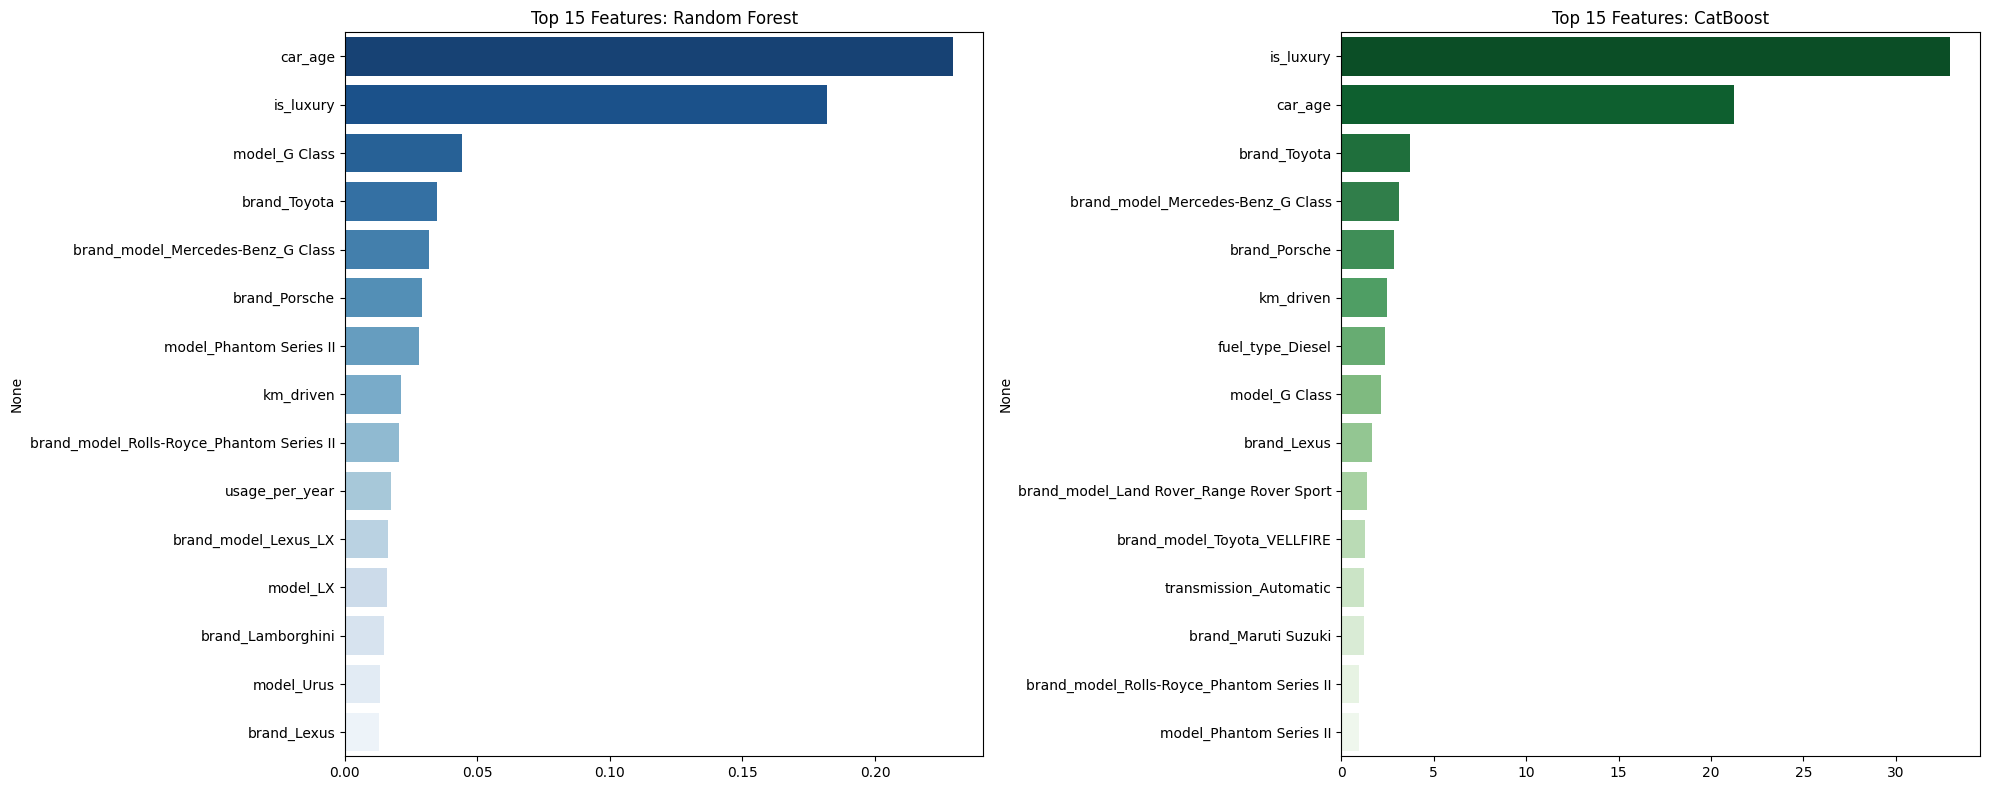

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Metrics Comparison
display(comparison_df.set_index('Model'))

# 2. Feature Importance Analysis
def get_feature_importance(model_name, regressor, preprocessor):
    # Get feature names after one-hot encoding
    ohe_features = list(preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features))
    all_feature_names = num_features + ohe_features

    importances = regressor.feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)
    return feat_imp

# Get importances for both (Top 15)
rf_pipeline = Pipeline([('pre', preprocessor), ('reg', RandomForestRegressor(random_state=42))])
rf_pipeline.fit(X_train, y_train)
rf_imp = get_feature_importance('Random Forest', rf_pipeline.named_steps['reg'], preprocessor)

cb_pipeline = Pipeline([('pre', preprocessor), ('reg', CatBoostRegressor(verbose=0, random_state=42))])
cb_pipeline.fit(X_train, y_train)
cb_imp = get_feature_importance('CatBoost', cb_pipeline.named_steps['reg'], preprocessor)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x=rf_imp.values, y=rf_imp.index, ax=ax1, palette='Blues_r')
ax1.set_title('Top 15 Features: Random Forest')

sns.barplot(x=cb_imp.values, y=cb_imp.index, ax=ax2, palette='Greens_r')
ax2.set_title('Top 15 Features: CatBoost')

plt.tight_layout()
plt.show()

### Side-by-Side Model Testing
Testing five specific models with fixed parameters:
- **Age**: 5 years
- **KM Driven**: 50,000
- **Transmission**: Manual
- **Fuel**: Petrol
- **Owner**: First

In [21]:
test_cars = [
    {'brand': 'Maruti Suzuki', 'model': 'Swift'},
    {'brand': 'Hyundai', 'model': 'Creta'},
    {'brand': 'Honda', 'model': 'City'},
    {'brand': 'Toyota', 'model': 'Innova'},
    {'brand': 'Toyota', 'model': 'Fortuner'}
]

comparison_results = []

for car in test_cars:
    # Construct the input matching engineering logic
    brand_model = f"{car['brand']}_{car['model']}"
    usage = 50000 / (5 + 1)
    is_p = 1 if car['brand'] in premium_brands else 0
    is_l = 1 if car['brand'] in luxury_brands else 0

    input_df = pd.DataFrame({
        'brand': [car['brand']],
        'model': [car['model']],
        'km_driven': [50000],
        'transmission': ['Manual'],
        'owner_type': ['first'],
        'fuel_type': ['Petrol'],
        'car_age': [5],
        'brand_model': [brand_model],
        'usage_per_year': [usage],
        'is_premium': [is_p],
        'is_luxury': [is_l],
        'ownership_score': [1]
    })

    price_rf = rf_pipeline.predict(input_df)[0]
    price_cb = cb_pipeline.predict(input_df)[0]

    comparison_results.append({
        'Car': f"{car['brand']} {car['model']}",
        'RF Prediction': f"₹{price_rf:,.2f}",
        'CatBoost Prediction': f"₹{price_cb:,.2f}",
        'Difference': f"₹{abs(price_rf - price_cb):,.2f}"
    })

display(pd.DataFrame(comparison_results))

,Car,RF Prediction,CatBoost Prediction,Difference
0,Maruti Suzuki Swift,"₹604,189.99","₹648,075.14","₹43,885.15"
1,Hyundai Creta,"₹1,108,550.00","₹916,828.78","₹191,721.22"
2,Honda City,"₹953,350.00","₹828,295.44","₹125,054.56"
3,Toyota Innova,"₹1,272,548.12","₹1,678,399.27","₹405,851.15"
4,Toyota Fortuner,"₹3,380,689.99","₹2,766,638.39","₹614,051.60"


## Deployment Package: Feature List & Sample Structure
This cell identifies the exact schema required by the exported pipeline.

In [22]:
import joblib
import pandas as pd

# Load model to inspect
model = joblib.load('car_price_model_v2.joblib')

# 1. Feature list from the preprocessor
num_cols = num_features
cat_cols = cat_features

print("--- EXPECTED INPUT COLUMNS ---")
print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

# 2. Sample Dataframe structure
sample_input = pd.DataFrame([{
    'brand': 'Maruti Suzuki',
    'model': 'Swift',
    'km_driven': 50000,
    'transmission': 'Manual',
    'owner_type': 'first',
    'fuel_type': 'Petrol',
    'car_age': 5,
    'brand_model': 'Maruti Suzuki_Swift',
    'usage_per_year': 8333.33,
    'is_premium': 0,
    'is_luxury': 0,
    'ownership_score': 1
}])

print("\n--- SAMPLE DATAFRAME FOR PREDICTION ---")
display(sample_input)

--- EXPECTED INPUT COLUMNS ---
Numerical: ['km_driven', 'car_age', 'usage_per_year', 'is_premium', 'is_luxury', 'ownership_score']
Categorical: ['brand', 'model', 'transmission', 'owner_type', 'fuel_type', 'brand_model']

--- SAMPLE DATAFRAME FOR PREDICTION ---


,brand,model,km_driven,transmission,owner_type,fuel_type,car_age,brand_model,usage_per_year,is_premium,is_luxury,ownership_score
0,Maruti Suzuki,Swift,50000,Manual,first,Petrol,5,Maruti Suzuki_Swift,8333.33,0,0,1


## Streamlit Application (app.py)
This code implements the full preprocessing logic and prediction UI.

In [23]:
streamlit_code = """
import streamlit as st
import pandas as pd
import joblib
from datetime import date

# Load the exported pipeline
model = joblib.load('car_price_model_v2.joblib')

# Define segment lists for feature engineering
premium_brands = ['Honda', 'Toyota', 'Volkswagen', 'Skoda']
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Volvo', 'Jaguar', 'Land Rover']
owner_map = {'First': 1, 'Second': 2, 'Third': 3, 'Fourth & Above': 4}

st.set_page_config(page_title="Car Price Predictor v2", layout="centered")
st.title("₹ Used Car Price Prediction System")
st.markdown("Enter car details below to estimate the current market value.")

with st.form("prediction_form"):
    col1, col2 = st.columns(2)

    with col1:
        brand = st.selectbox("Brand", sorted(['Maruti Suzuki', 'Hyundai', 'Honda', 'Toyota', 'Mahindra', 'Ford', 'Volkswagen', 'BMW', 'Mercedes-Benz', 'Audi', 'Skoda', 'Renault', 'Tata']))
        model_name = st.text_input("Model (e.g., Swift, City, Innova)", value="Swift")
        year = st.number_input("Manufacturing Year", min_value=1990, max_value=date.today().year, value=2018)
        km_driven = st.number_input("Kilometers Driven", min_value=0, value=50000)

    with col2:
        transmission = st.selectbox("Transmission", ["Manual", "Automatic"])
        fuel_type = st.selectbox("Fuel Type", ["Petrol", "Diesel", "CNG", "LPG"])
        owner_type = st.selectbox("Owner Type", ["First", "Second", "Third", "Fourth & Above"])

    submit = st.form_submit_button("Predict Price")

if submit:
    # 1. Feature Engineering (Match Pipeline Expectation)
    current_year = date.today().year
    car_age = current_year - year
    brand_model = f"{brand}_{model_name}"
    usage_per_year = km_driven / (car_age + 1)
    is_premium = 1 if brand in premium_brands else 0
    is_luxury = 1 if brand in luxury_brands else 0
    ownership_score = owner_map.get(owner_type, 1)

    # 2. Create input dataframe with exact column names
    input_data = pd.DataFrame({
        'brand': [brand],
        'model': [model_name],
        'km_driven': [float(km_driven)],
        'transmission': [transmission],
        'owner_type': [owner_type.lower()],
        'fuel_type': [fuel_type],
        'car_age': [car_age],
        'brand_model': [brand_model],
        'usage_per_year': [usage_per_year],
        'is_premium': [is_premium],
        'is_luxury': [is_luxury],
        'ownership_score': [ownership_score]
    })

    # 3. Prediction
    prediction = model.predict(input_data)[0]

    st.success(f"### Estimated Selling Price: ₹ {prediction:,.2f}")
    st.info(f"**Details:** Age: {car_age} years | Segment: {'Luxury' if is_luxury else 'Premium' if is_premium else 'Standard'}")
"""

with open('app.py', 'w') as f:
    f.write(streamlit_code.strip())

print("app.py generated successfully.")

app.py generated successfully.


## requirements.txt
This file lists the dependencies for deployment (e.g., Streamlit, CatBoost, Scikit-Learn).

In [24]:
requirements = """
streamlit
pandas
numpy
scikit-learn
joblib
catboost
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("requirements.txt generated successfully.")

requirements.txt generated successfully.


## Deployment File Verification
Checking the contents of the generated deployment package files.

In [25]:
!cat app.py

import streamlit as st
import pandas as pd
import joblib
from datetime import date

# Load the exported pipeline
model = joblib.load('car_price_model_v2.joblib')

# Define segment lists for feature engineering
premium_brands = ['Honda', 'Toyota', 'Volkswagen', 'Skoda']
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Volvo', 'Jaguar', 'Land Rover']
owner_map = {'First': 1, 'Second': 2, 'Third': 3, 'Fourth & Above': 4}

st.set_page_config(page_title="Car Price Predictor v2", layout="centered")
st.title("₹ Used Car Price Prediction System")
st.markdown("Enter car details below to estimate the current market value.")

with st.form("prediction_form"):
    col1, col2 = st.columns(2)
    
    with col1:
        brand = st.selectbox("Brand", sorted(['Maruti Suzuki', 'Hyundai', 'Honda', 'Toyota', 'Mahindra', 'Ford', 'Volkswagen', 'BMW', 'Mercedes-Benz', 'Audi', 'Skoda', 'Renault', 'Tata']))
        model_name = st.text_input("Model (e.g., Swift, City, Innova)", value="Swift")
        year = s

In [26]:
!cat requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib
catboost

## Feature Engineering Verification Test
Testing the processing logic for a 2021 Maruti Swift.

In [27]:
import joblib
import pandas as pd
from datetime import date

# User Inputs
user_input = {
    'brand': 'Maruti Suzuki',
    'model': 'Swift',
    'year': 2021,
    'km_driven': 50000,
    'transmission': 'Manual',
    'owner_type': 'first',
    'fuel_type': 'Petrol'
}

# 1. Internal Logic Simulation
current_year = date.today().year
car_age = current_year - user_input['year']
brand_model = f"{user_input['brand']}_{user_input['model']}"
usage_per_year = user_input['km_driven'] / (car_age + 1)

# Segment & Score Mappings
premium_brands = ['Honda', 'Toyota', 'Volkswagen', 'Skoda']
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Volvo', 'Jaguar', 'Land Rover']
owner_map = {'first': 1, 'second': 2, 'third': 3, 'fourth & above': 4}

is_premium = 1 if user_input['brand'] in premium_brands else 0
is_luxury = 1 if user_input['brand'] in luxury_brands else 0
ownership_score = owner_map.get(user_input['owner_type'].lower(), 1)

# 2. Construct Final Dataframe
final_input_df = pd.DataFrame({
    'brand': [user_input['brand']],
    'model': [user_input['model']],
    'km_driven': [float(user_input['km_driven'])],
    'transmission': [user_input['transmission']],
    'owner_type': [user_input['owner_type']],
    'fuel_type': [user_input['fuel_type']],
    'car_age': [car_age],
    'brand_model': [brand_model],
    'usage_per_year': [usage_per_year],
    'is_premium': [is_premium],
    'is_luxury': [is_luxury],
    'ownership_score': [ownership_score]
})

print("--- Final Dataframe Passed to Model ---")
display(final_input_df)

# 3. Execution
model = joblib.load('car_price_model_v2.joblib')
prediction = model.predict(final_input_df)[0]
print(f"\nPrediction Result: ₹{prediction:,.2f}")

--- Final Dataframe Passed to Model ---


,brand,model,km_driven,transmission,owner_type,fuel_type,car_age,brand_model,usage_per_year,is_premium,is_luxury,ownership_score
0,Maruti Suzuki,Swift,50000.0,Manual,first,Petrol,5,Maruti Suzuki_Swift,8333.333333,0,0,1



Prediction Result: ₹648,075.14


In [28]:
import os

for f in os.listdir("/content"):
    print(f)

.config
requirements.txt
car_price_model_v2.joblib
used_cars_dataset_v2.csv
app.py
catboost_info
sample_data


In [29]:
import os

files = [
    "app.py",
    "requirements.txt",
    "car_price_model_v2.joblib"
]

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f)/(1024*1024)
        print(f"{f}: {size:.2f} MB")

app.py: 0.00 MB
requirements.txt: 0.00 MB
car_price_model_v2.joblib: 1.12 MB


In [30]:
with open("app.py", "r") as f:
    print(f.read()[:2000])


import streamlit as st
import pandas as pd
import joblib
from datetime import date

# Load the exported pipeline
model = joblib.load('car_price_model_v2.joblib')

# Define segment lists for feature engineering
premium_brands = ['Honda', 'Toyota', 'Volkswagen', 'Skoda']
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Volvo', 'Jaguar', 'Land Rover']
owner_map = {'First': 1, 'Second': 2, 'Third': 3, 'Fourth & Above': 4}

st.set_page_config(page_title="Car Price Predictor v2", layout="centered")
st.title("₹ Used Car Price Prediction System")
st.markdown("Enter car details below to estimate the current market value.")

with st.form("prediction_form"):
    col1, col2 = st.columns(2)
    
    with col1:
        brand = st.selectbox("Brand", sorted(['Maruti Suzuki', 'Hyundai', 'Honda', 'Toyota', 'Mahindra', 'Ford', 'Volkswagen', 'BMW', 'Mercedes-Benz', 'Audi', 'Skoda', 'Renault', 'Tata']))
        model_name = st.text_input("Model (e.g., Swift, City, Innova)", value="Swift")
        year = s

In [31]:
with open("requirements.txt", "r") as f:
    print(f.read())

streamlit
pandas
numpy
scikit-learn
joblib
catboost
